In [ ]:
import numpy as np
from math import sin, sqrt
import matplotlib.pyplot as plt

In [111]:
#Numerical values to use in substitutions

m = 0.462
g = 9.81
d = 0.42
delta = 0.65
r = 0.123
R = 2200
L0 = 0.125
L1 = 0.0241
alpha = 1.2
c = 6.811
k = 1885
b = 10.4
tau = 0.03
phi = np.deg2rad(41)

x_1e = 0.5
x_2e = 0
x_3e = (delta - x_1e)*sqrt( (k*(x_1e-d) - m*g*sin(phi)) / c)

V_e = x_3e * R

$\gamma$ compared with its linearised counterparts

423.07802198470284


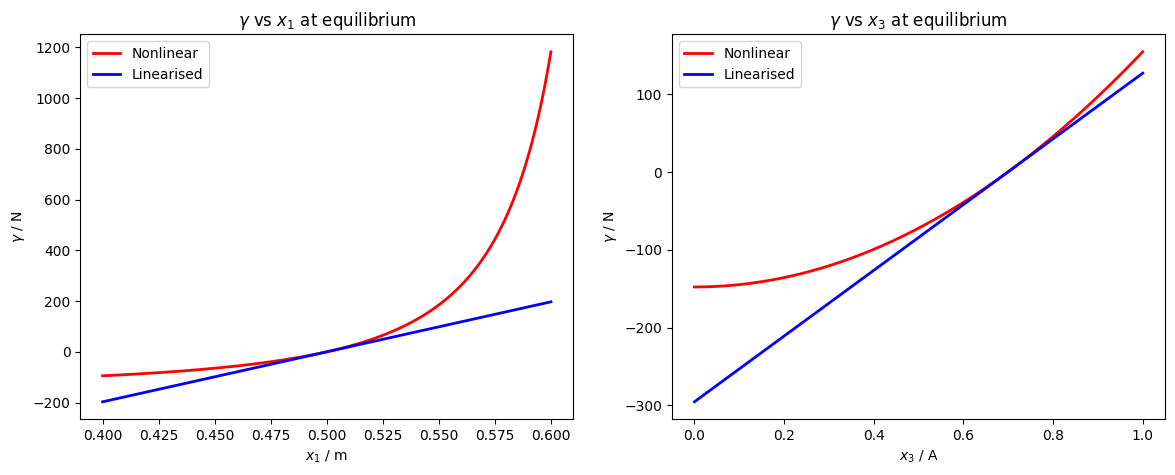

In [145]:
x1 = np.linspace(0.4, 0.6, 1000)
gamma_nonlinear_x1 = c*(x_3e / ((delta - x1)))**2  - (x_3e**2 * c) / ((delta - x_1e))**2 

d_dx1 = ( (x_3e**2*2*c) / ( (delta-x_1e)**3 ) ) 

gamma_linear_x1 = d_dx1*(x1-x_1e)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(x1, gamma_nonlinear_x1, 'r-', linewidth=2, label="Nonlinear")
ax1.plot(x1, gamma_linear_x1 , 'b-', linewidth=2, label="Linearised")
ax1.set_title(r"$\gamma$ vs $x_1$ at equilibrium")
ax1.set_xlabel(r"$x_1$ / m")
ax1.set_ylabel(r"$\gamma$ / N")
ax1.legend()


x3 = np.linspace(0,1, 1000)

gamma_nonlinear_x3 = c*(x3 / ((delta - x_1e)))**2 - (x_3e**2 * c) / (delta - x_1e)**2 

d_dx3 = ( (x_3e*2*c) / ( (delta-x_1e)**2 ) )
print(d_dx3)

gamma_linear_x3 = d_dx3*(x3-x_3e)

ax2.plot(x3, gamma_nonlinear_x3, 'r-', linewidth=2, label="Nonlinear")
ax2.plot(x3,  gamma_linear_x3, 'b-', linewidth=2, label="Linearised")
ax2.set_title(r'$\gamma$ vs $x_3$ at equilibrium')
ax2.set_xlabel(r"$x_3$ / A")
ax2.set_ylabel(r"$\gamma$ / N")
ax2.legend()


plt.show()

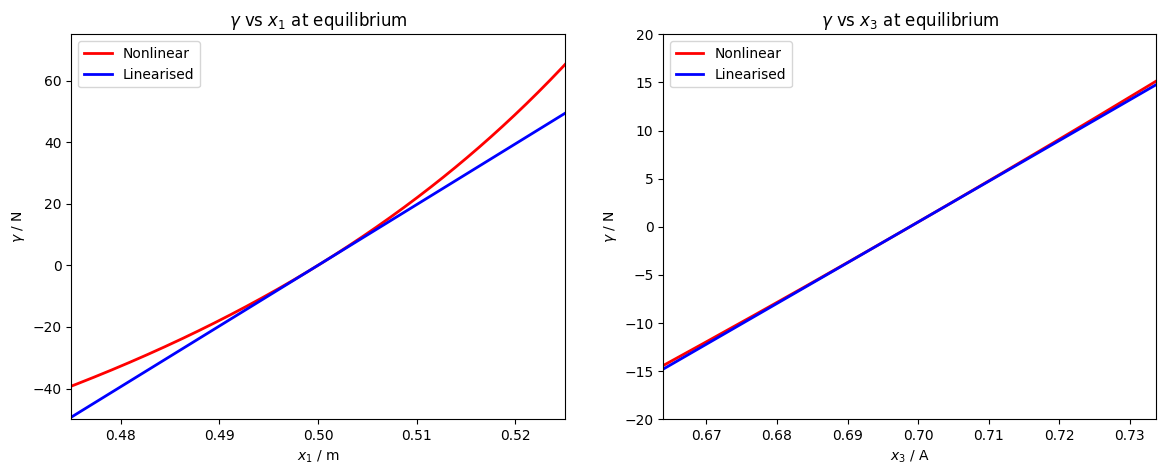

In [147]:
#Closeups around the setpoint of 0.5m

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


ax1.plot(x1, gamma_nonlinear_x1, 'r-', linewidth=2, label="Nonlinear")
ax1.plot(x1, gamma_linear_x1 , 'b-', linewidth=2, label="Linearised")
ax1.set_xlim(x_1e*0.95, x_1e*1.05)
ax1.set_ylim(-50, 75)
ax1.set_title(r"$\gamma$ vs $x_1$ at equilibrium")
ax1.set_xlabel(r"$x_1$ / m")
ax1.set_ylabel(r"$\gamma$ / N")
ax1.legend()



ax2.plot(x3, gamma_nonlinear_x3, 'r-', linewidth=2, label="Nonlinear")

#User may comment/uncomment this line to see the overlap between linear and nonlinear graphs
ax2.plot(x3,  gamma_linear_x3, 'b-', linewidth=2, label="Linearised")


ax2.set_xlim(x_3e*0.95, x_3e*1.05)
ax2.set_ylim(-20, 20)
ax2.set_title(r'$\gamma$ vs $x_3$ at equilibrium')
ax2.set_xlabel(r"$x_3$ / A")
ax2.set_ylabel(r"$\gamma$ / N")
ax2.legend()

#plt.savefig("gamma_linearisation.eps")
plt.show()

$\zeta$ compared with its linearised counterparts

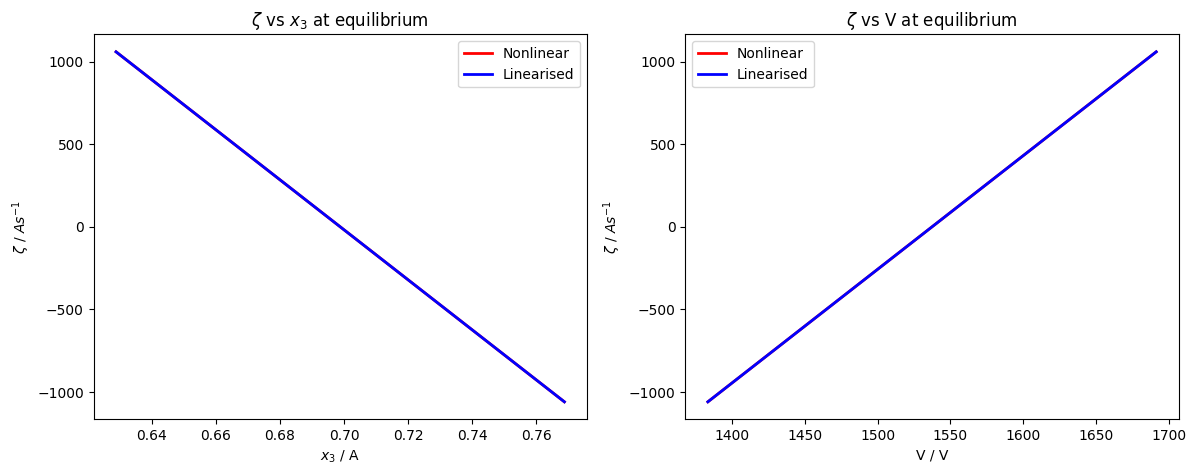

In [148]:
V_eq = (V_e - x_3e*R)/(L0+L1*np.exp(-alpha*(delta - x_1e)))


x3 = np.linspace(x_3e*0.9, x_3e*1.1, 1000)

zeta_nonlinear_x3 = (V_e - x3*R) / (L0+L1*np.exp(-alpha*(delta - x_1e))) 

d_dx3 = - (R) / (L0 + L1 * np.exp(-alpha * (delta - x_1e)))
zeta_linear_x3 = d_dx3*(x3-x_3e)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#zeta vs x3
ax1.plot(x3, zeta_nonlinear_x3, 'r-', linewidth=2, label="Nonlinear")

#User may comment/uncomment this line to see the overlap between linear and nonlinear graphs
ax1.plot(x3, zeta_linear_x3, 'b-', linewidth=2, label="Linearised")


ax1.set_title(r"$\zeta$ vs $x_3$ at equilibrium")
ax1.set_xlabel(r"$x_3$ / A")
ax1.set_ylabel(r"$\zeta$ / $As^{-1}$")
ax1.legend()



V = np.linspace(x_3e*R*0.9, x_3e*R*1.1, 1000)

zeta_nonlinear_V = (V - x_3e*R)/(L0+L1*np.exp(-alpha*(delta - x_1e)))

d_dV = 1 / (L0 + L1 * np.exp(-alpha * (delta - x_1e)))
zeta_linear_V = d_dV*(V-V_e)

#zeta vs V
ax2.plot(V, zeta_nonlinear_V, 'r-', linewidth=2, label="Nonlinear")

#User may comment/uncomment this line to see the overlap between linear and nonlinear graphs
ax2.plot(V, zeta_linear_V, 'b-', linewidth=2, label="Linearised")


ax2.set_title(r"$\zeta$ vs V at equilibrium")
ax2.set_xlabel(r"V / V")
ax2.set_ylabel(r"$\zeta$ / $As^{-1}$")
ax2.legend()

#plt.savefig("zeta_linearisation.eps")
plt.show()